In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import os
import s3fs
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Xarray dark mode hack
from IPython.display import HTML, display

display(HTML("""
<style>
    .xr-wrap {
        --xr-background-color-row-odd: rgba(100, 100, 100, 0.10) !important;
        --xr-background-color-row-even: rgba(30, 30, 30, 0.10) !important;
    }
</style>
"""))

In [ ]:
fs = s3fs.S3FileSystem(
    key=os.environ["AWS_ACCESS_KEY_ID"],
    secret=os.environ["AWS_SECRET_ACCESS_KEY"],
    client_kwargs={"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    config_kwargs={
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
                }
)

storage_options = {
    "client_kwargs": {"endpoint_url": os.environ["S3_ENDPOINT_URL"]},
    "config_kwargs": {
        "request_checksum_calculation": "when_required",
        "response_checksum_validation": "when_required",
    },
}

fs.get('gaia/cjense/data/velocity/ZI_79N_velseries_monthly.nc', '/tmp/ZI_79N_velseries_monthly.nc')
fs.get('gaia/cjense/data/velocity/ZI_79N_velseries_612day.nc', '/tmp/ZI_79N_velseries_612day.nc')
fs.get('gaia/cjense/data/velocity/ZI_79N_velseries_optical_individual_78.95N_ZI.nc', '/tmp/ZI_79N_velseries_optical_individual_78.95N_ZI.nc')
fs.get('gaia/cjense/data/velocity/ZI_79N_velseries_optical_individual_E79.40N_79N.nc', '/tmp/ZI_79N_velseries_optical_individual_E79.40N_79N.nc')

[None]

In [3]:
monthly = xr.open_dataset('/tmp/ZI_79N_velseries_monthly.nc')
monthly

<xarray.Dataset> Size: 35MB
Dimensions:      (time: 3, band: 3, y: 1201, x: 801)
Coordinates:
  * time         (time) datetime64[ns] 24B 2014-12-16 ... 2015-02-14T12:00:00
    time1        (time) datetime64[ns] 24B ...
    time2        (time) datetime64[ns] 24B ...
  * band         (band) <U2 24B 'vx' 'vy' 'vv'
    _FillValue   (band) float64 24B ...
  * y            (y) float64 10kB -9.8e+05 -9.802e+05 ... -1.22e+06 -1.22e+06
  * x            (x) float64 6kB 4e+05 4.002e+05 4.004e+05 ... 5.598e+05 5.6e+05
    name         <U4 16B ...
Data variables:
    spatial_ref  int64 8B ...
    VelocityMap  (time, band, y, x) float32 35MB ...

In [4]:
six12 = xr.open_dataset('/tmp/ZI_79N_velseries_612day.nc')
six12

<xarray.Dataset> Size: 6GB
Dimensions:      (time: 494, band: 3, y: 1201, x: 801)
Coordinates:
  * time         (time) datetime64[ns] 4kB 2015-01-06T12:00:00 ... 2025-12-21...
    time1        (time) datetime64[ns] 4kB ...
    time2        (time) datetime64[ns] 4kB ...
  * band         (band) <U2 24B 'vx' 'vy' 'vv'
    _FillValue   (band) float64 24B ...
  * y            (y) float64 10kB -9.8e+05 -9.802e+05 ... -1.22e+06 -1.22e+06
  * x            (x) float64 6kB 4e+05 4.002e+05 4.004e+05 ... 5.598e+05 5.6e+05
    name         <U4 16B ...
Data variables:
    spatial_ref  int64 8B ...
    VelocityMap  (time, band, y, x) float32 6GB ...

In [5]:
individual_ZI = xr.open_dataset('/tmp/ZI_79N_velseries_optical_individual_78.95N_ZI.nc')
individual_ZI

<xarray.Dataset> Size: 163MB
Dimensions:      (time: 45, band: 3, y: 577, x: 522)
Coordinates:
  * time         (time) datetime64[ns] 360B 2000-06-15T12:00:00 ... 2014-09-1...
    time1        (time) datetime64[ns] 360B ...
    time2        (time) datetime64[ns] 360B ...
  * band         (band) <U2 24B 'vx' 'vy' 'vv'
    _FillValue   (band) float64 24B ...
  * y            (y) float64 5kB -1.066e+06 -1.066e+06 ... -1.124e+06 -1.124e+06
  * x            (x) float64 4kB 4.724e+05 4.725e+05 ... 5.244e+05 5.245e+05
    name         <U4 16B ...
Data variables:
    spatial_ref  int64 8B ...
    VelocityMap  (time, band, y, x) float32 163MB ...

In [6]:
individual_79N = xr.open_dataset('/tmp/ZI_79N_velseries_optical_individual_E79.40N_79N.nc')
individual_79N

<xarray.Dataset> Size: 320MB
Dimensions:      (time: 50, band: 3, y: 801, x: 666)
Coordinates:
  * time         (time) datetime64[ns] 400B 2000-06-15T12:00:00 ... 2014-09-1...
    time1        (time) datetime64[ns] 400B ...
    time2        (time) datetime64[ns] 400B ...
  * band         (band) <U2 24B 'vx' 'vy' 'vv'
    _FillValue   (band) float64 24B ...
  * y            (y) float64 6kB -1.017e+06 -1.017e+06 ... -1.097e+06 -1.097e+06
  * x            (x) float64 5kB 4.193e+05 4.194e+05 ... 4.857e+05 4.858e+05
    name         <U4 16B ...
Data variables:
    spatial_ref  int64 8B ...
    VelocityMap  (time, band, y, x) float32 320MB ...

In [7]:
# Extract bounds for each dataset
bounds = {
    'monthly': {
        'x': (monthly.x.values.min(), monthly.x.values.max()),
        'y': (monthly.y.values.min(), monthly.y.values.max()),
        'time': (monthly.time.values.min(), monthly.time.values.max()),
    },
    'six12day': {
        'x': (six12.x.values.min(), six12.x.values.max()),
        'y': (six12.y.values.min(), six12.y.values.max()),
        'time': (six12.time.values.min(), six12.time.values.max()),
    },
    'individual_ZI': {
        'x': (individual_ZI.x.values.min(), individual_ZI.x.values.max()),
        'y': (individual_ZI.y.values.min(), individual_ZI.y.values.max()),
        'time': (individual_ZI.time.values.min(), individual_ZI.time.values.max()),
    },
    'individual_79N': {
        'x': (individual_79N.x.values.min(), individual_79N.x.values.max()),
        'y': (individual_79N.y.values.min(), individual_79N.y.values.max()),
        'time': (individual_79N.time.values.min(), individual_79N.time.values.max()),
    }
}

# Print bounds for reference
for name, b in bounds.items():
    print(f"{name}:")
    print(f"  x: {b['x'][0]:.0f} to {b['x'][1]:.0f} (width: {b['x'][1]-b['x'][0]:.0f})")
    print(f"  y: {b['y'][0]:.0f} to {b['y'][1]:.0f} (height: {b['y'][0]-b['y'][1]:.0f})")
    print(f"  time: {pd.Timestamp(b['time'][0])} to {pd.Timestamp(b['time'][1])}")
    print()

monthly:
  x: 400000 to 560000 (width: 160000)
  y: -1220000 to -980000 (height: -240000)
  time: 2014-12-16 00:00:00 to 2015-02-14 12:00:00

six12day:
  x: 400000 to 560000 (width: 160000)
  y: -1220000 to -980000 (height: -240000)
  time: 2015-01-06 12:00:00 to 2025-12-21 12:00:00

individual_ZI:
  x: 472400 to 524500 (width: 52100)
  y: -1123700 to -1066100 (height: -57600)
  time: 2000-06-15 12:00:00 to 2014-09-15 12:00:00

individual_79N:
  x: 419300 to 485800 (width: 66500)
  y: -1097100 to -1017100 (height: -80000)
  time: 2000-06-15 12:00:00 to 2014-09-15 12:00:00



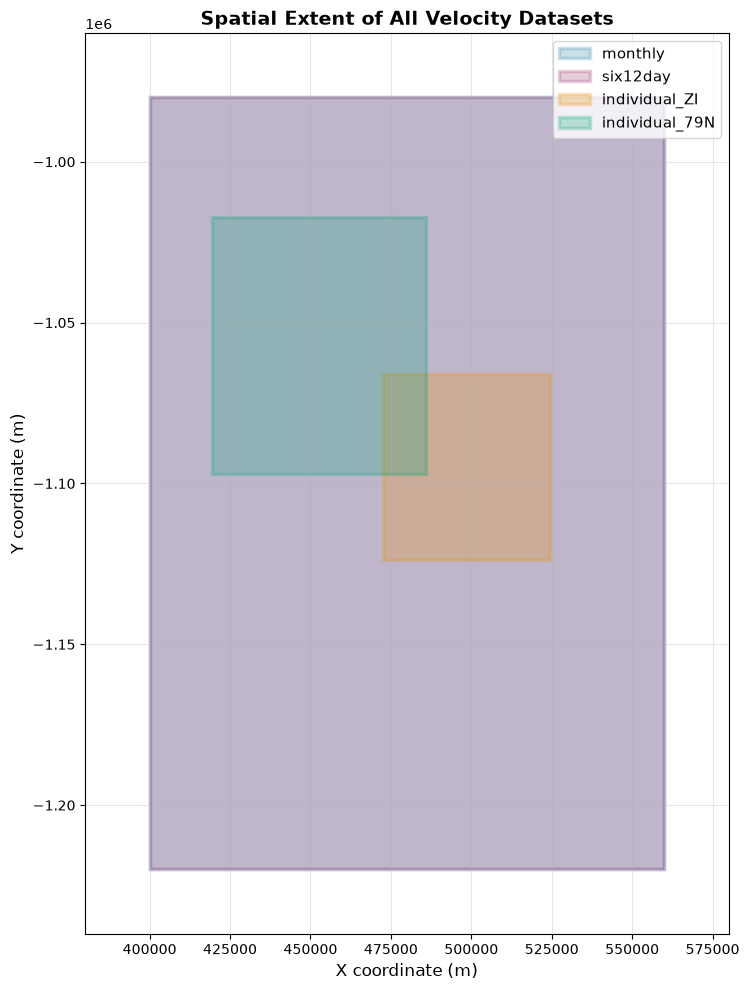

In [8]:
# Plot spatial extent overlap for all 4 datasets
fig, ax = plt.subplots(figsize=(12, 10))

colors = {
    'monthly': '#2E86AB',
    'six12day': '#A23B72',
    'individual_ZI': '#F18F01',
    'individual_79N': '#06A77D'
}

for name, b in bounds.items():
    x_min, x_max = b['x']
    y_min, y_max = b['y']
    width = x_max - x_min
    height = y_min - y_max
    
    rect = mpatches.Rectangle(
        (x_min, y_max), width, height,
        linewidth=2.5, edgecolor=colors[name], facecolor=colors[name],
        alpha=0.25, label=name
    )
    ax.add_patch(rect)

# Set proper axis limits
all_x = [b['x'][0] for b in bounds.values()] + [b['x'][1] for b in bounds.values()]
all_y = [b['y'][0] for b in bounds.values()] + [b['y'][1] for b in bounds.values()]
margin = 20000
ax.set_xlim(min(all_x) - margin, max(all_x) + margin)
ax.set_ylim(min(all_y) - margin, max(all_y) + margin)

ax.set_xlabel('X coordinate (m)', fontsize=12)
ax.set_ylabel('Y coordinate (m)', fontsize=12)
ax.set_title('Spatial Extent of All Velocity Datasets', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [9]:
# Regrid individual_79N to match the spatial grid of monthly/six12day
print("Regridding individual_79N to match monthly/six12day grid...")
individual_79N_regridded = individual_79N.interp_like(monthly, method='nearest')
print(f"  Regridded individual_79N shape: {individual_79N_regridded.VelocityMap.shape}")

# Regrid individual_ZI to match the spatial grid of monthly/six12day
print("Regridding individual_ZI to match monthly/six12day grid...")
individual_ZI_regridded = individual_ZI.interp_like(monthly, method='nearest')
print(f"  Regridded individual_ZI shape: {individual_ZI_regridded.VelocityMap.shape}")

# Concatenate all four datasets
print("\nConcatenating all 4 datasets in time order...")

# Remove overlap: keep only monthly data before six12day starts
monthly_filtered = monthly.where(monthly.time < six12.time.values[0], drop=True)

print(f"  Individual_79N (regridded): {len(individual_79N_regridded.time)} timesteps")
print(f"  Individual_ZI (regridded): {len(individual_ZI_regridded.time)} timesteps")
print(f"  Monthly (after removing overlap): {len(monthly_filtered.time)} timesteps")
print(f"  Six12day: {len(six12.time)} timesteps")

# Concatenate in chronological order
# First sort by time to ensure proper ordering
datasets_to_concat = [individual_79N_regridded, individual_ZI_regridded, monthly_filtered, six12]
combined = xr.concat(datasets_to_concat, dim='time')
combined = combined.sortby('time')

print(f"\n✓ Combined dataset created")
print(f"  Shape: {combined.VelocityMap.shape}")
print(f"  Time range: {pd.Timestamp(combined.time.values.min())} to {pd.Timestamp(combined.time.values.max())}")
print(f"  Total timesteps: {len(combined.time)}")
print(f"  Grid: {combined.sizes['y']} × {combined.sizes['x']}")
nan_total = combined.VelocityMap.isnull().sum().values
total = combined.VelocityMap.size
print(f"  Valid data: {100 * (1 - nan_total / total):.1f}%")

# Drop extra time coordinates (time1, time2) if they exist
coords_to_drop = [c for c in combined.coords if c.startswith('time') and c != 'time']
if coords_to_drop:
    combined_clean = combined.drop_vars(coords_to_drop)
    print(f"  Dropped coordinates: {coords_to_drop}")
else:
    combined_clean = combined

combined

Regridding individual_79N to match monthly/six12day grid...
  Regridded individual_79N shape: (3, 3, 1201, 801)
Regridding individual_ZI to match monthly/six12day grid...
  Regridded individual_ZI shape: (3, 3, 1201, 801)

Concatenating all 4 datasets in time order...
  Individual_79N (regridded): 3 timesteps
  Individual_ZI (regridded): 3 timesteps
  Monthly (after removing overlap): 1 timesteps
  Six12day: 494 timesteps

✓ Combined dataset created
  Shape: (501, 3, 1201, 801)
  Time range: 2014-12-16 00:00:00 to 2025-12-21 12:00:00
  Total timesteps: 501
  Grid: 1201 × 801
  Valid data: 49.7%
  Dropped coordinates: ['time1', 'time2']


<xarray.Dataset> Size: 6GB
Dimensions:      (time: 501, band: 3, y: 1201, x: 801)
Coordinates:
  * time         (time) datetime64[ns] 4kB 2014-12-16 ... 2025-12-21T12:00:00
    time1        (time) datetime64[ns] 4kB NaT NaT ... 2025-12-04 2025-12-16
    time2        (time) datetime64[ns] 4kB NaT NaT ... 2025-12-15 2025-12-27
  * band         (band) <U2 24B 'vx' 'vy' 'vv'
    _FillValue   (band) float64 24B -2e+09 -2e+09 -1.0
  * y            (y) float64 10kB -9.8e+05 -9.802e+05 ... -1.22e+06 -1.22e+06
  * x            (x) float64 6kB 4e+05 4.002e+05 4.004e+05 ... 5.598e+05 5.6e+05
    name         <U4 16B 'None'
Data variables:
    spatial_ref  (time) float64 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    VelocityMap  (time, band, y, x) float32 6GB nan nan nan ... 4.922 9.117

In [ ]:
combined.to_zarr('s3://gaia/cjense/data/velocity/ZI_79N_velseries_combined.zarr', consolidated=False, storage_options=storage_options, mode='w-')